In [4]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd, pingouin as pg
from scipy.io import loadmat
from pprint import pprint
from scipy.signal import butter, filtfilt

# Extraction function
def get_epoch(channel, trial, file):
    start = file['datastart'][channel-1, trial] - 1
    end = file['dataend'][channel-1, trial]
    return file['data'][0][int(start):int(end)]

In [5]:
# Load data
mat = loadmat('Hanif_Auditory_1.mat')

Sample rate: 1000 Hz


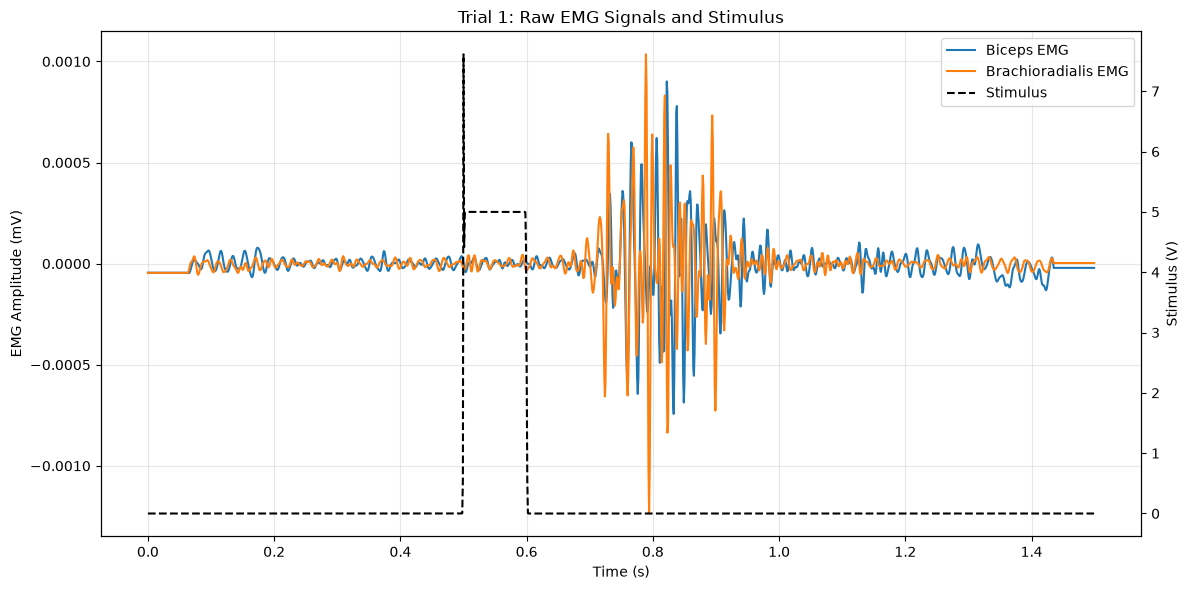

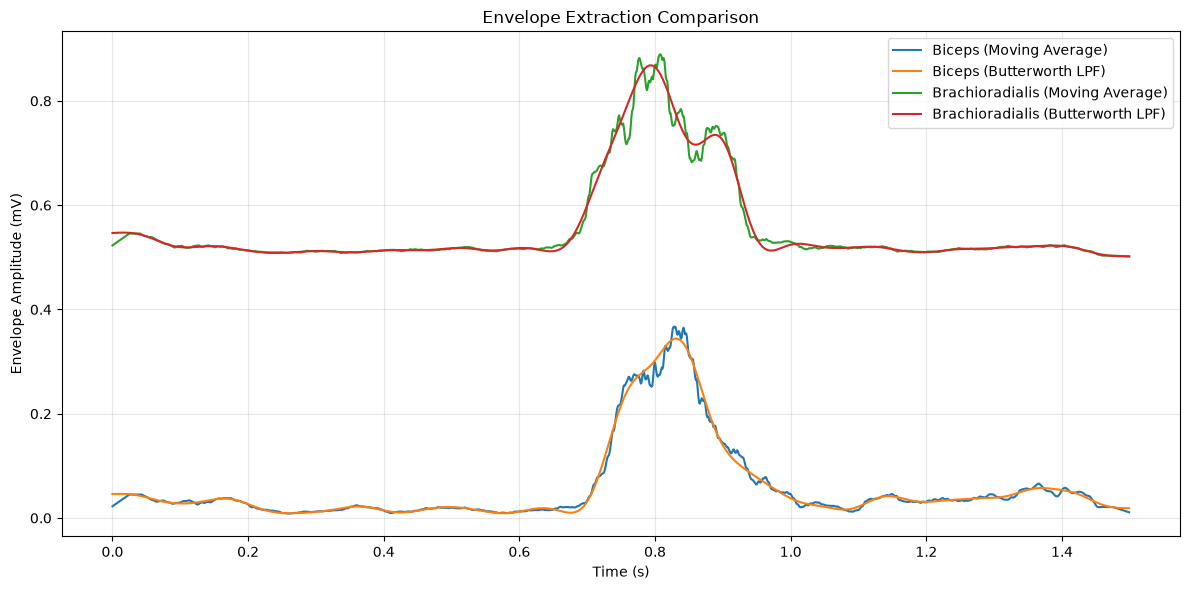

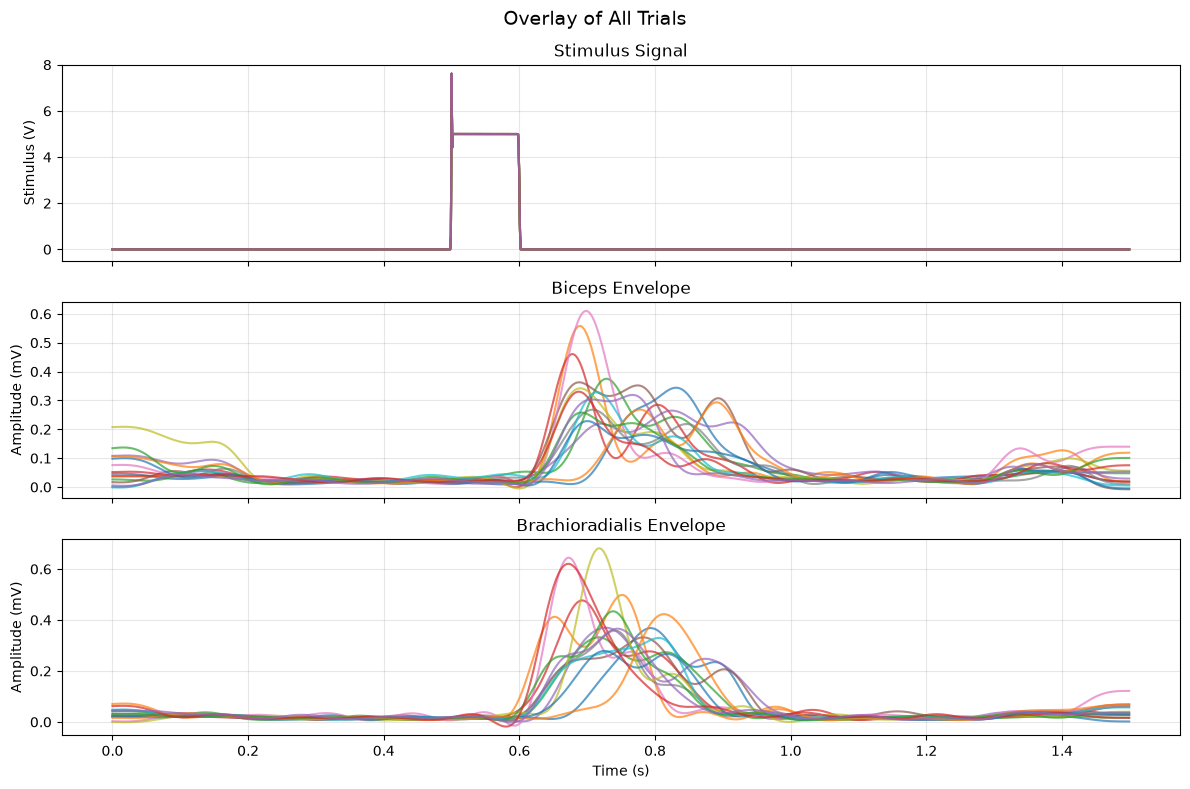

Biceps Trial 1: 203.0 ms
Biceps Trial 2: 126.0 ms
Biceps Trial 3: 144.0 ms
Biceps Trial 4: 121.0 ms
Biceps Trial 5: 152.0 ms
Biceps Trial 6: 117.0 ms
Biceps Trial 7: 132.0 ms
Biceps Trial 8: 131.0 ms
Biceps Trial 9: 146.0 ms
Biceps Trial 10: 149.0 ms
Biceps Trial 11: 141.0 ms
Biceps Trial 12: 211.0 ms
Biceps Trial 13: 136.0 ms
Biceps Trial 14: 119.0 ms
Biceps Trial 15: 132.0 ms


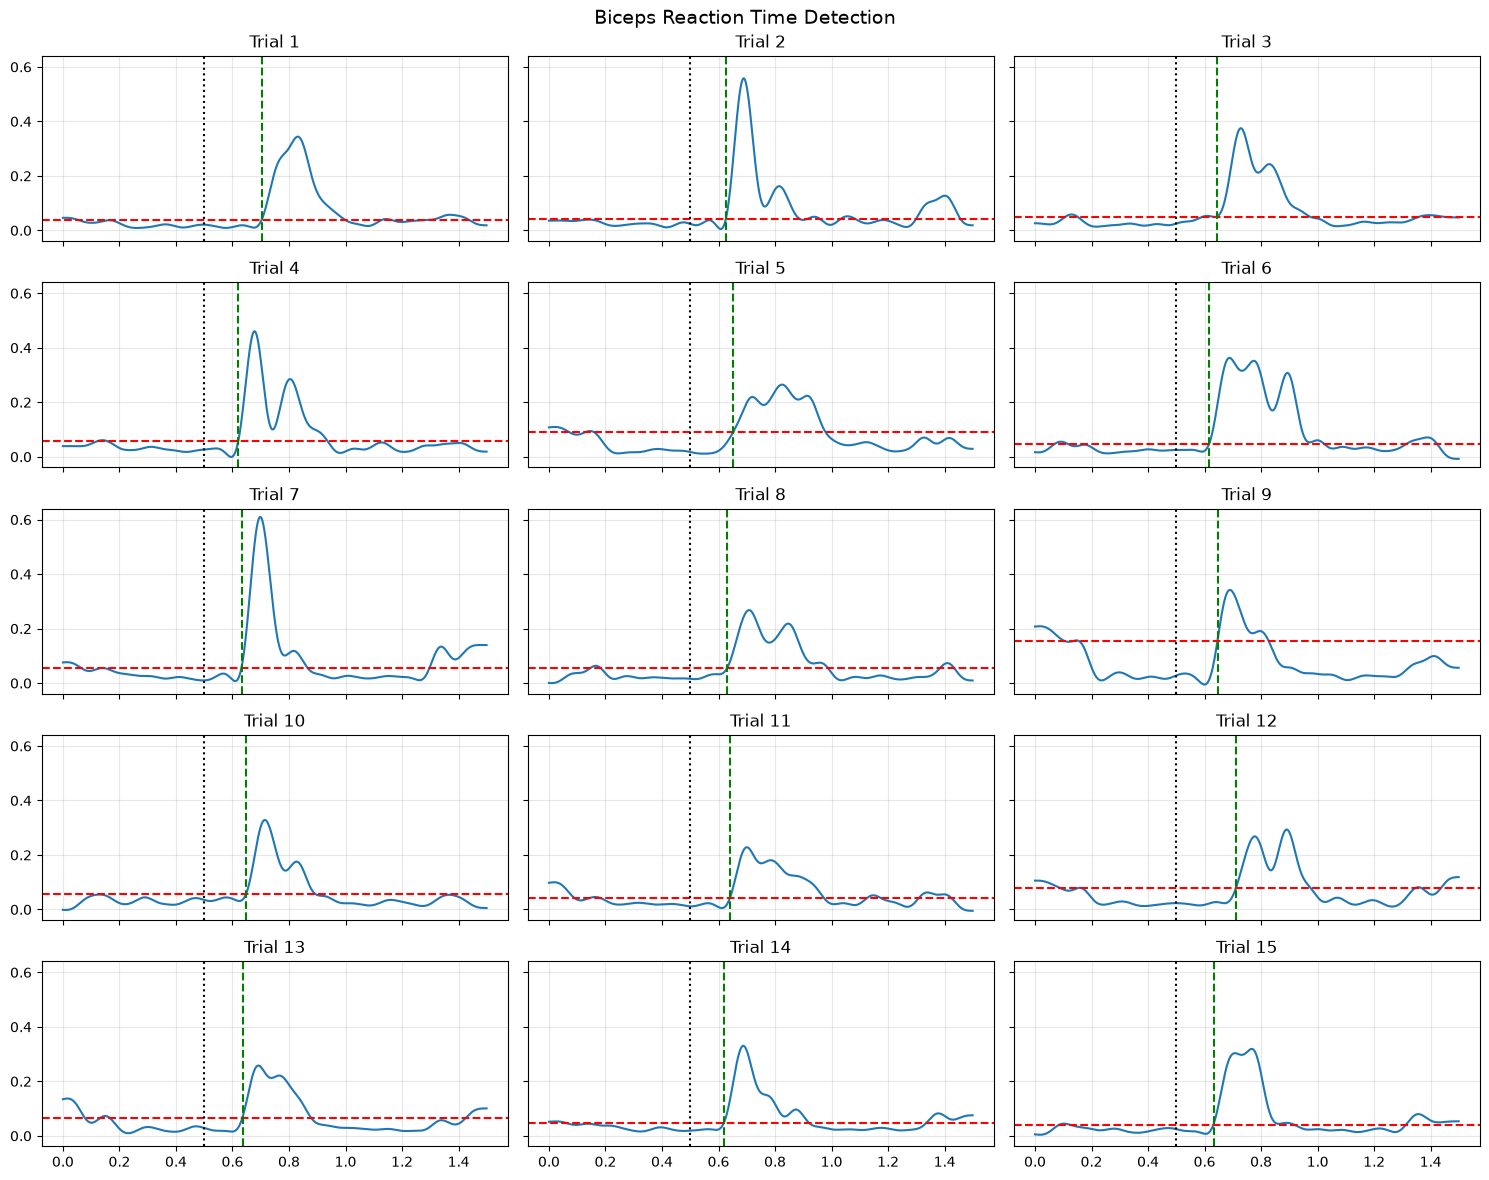

Brachioradialis Trial 1: 167.0 ms
Brachioradialis Trial 2: 83.0 ms
Brachioradialis Trial 3: 113.0 ms
Brachioradialis Trial 4: 80.0 ms
Brachioradialis Trial 5: 129.0 ms
Brachioradialis Trial 6: 104.0 ms
Brachioradialis Trial 7: 112.0 ms
Brachioradialis Trial 8: 106.0 ms
Brachioradialis Trial 9: 75.0 ms
Brachioradialis Trial 10: 109.0 ms
Brachioradialis Trial 11: 124.0 ms
Brachioradialis Trial 12: 165.0 ms
Brachioradialis Trial 13: 92.0 ms
Brachioradialis Trial 14: 101.0 ms
Brachioradialis Trial 15: 114.0 ms


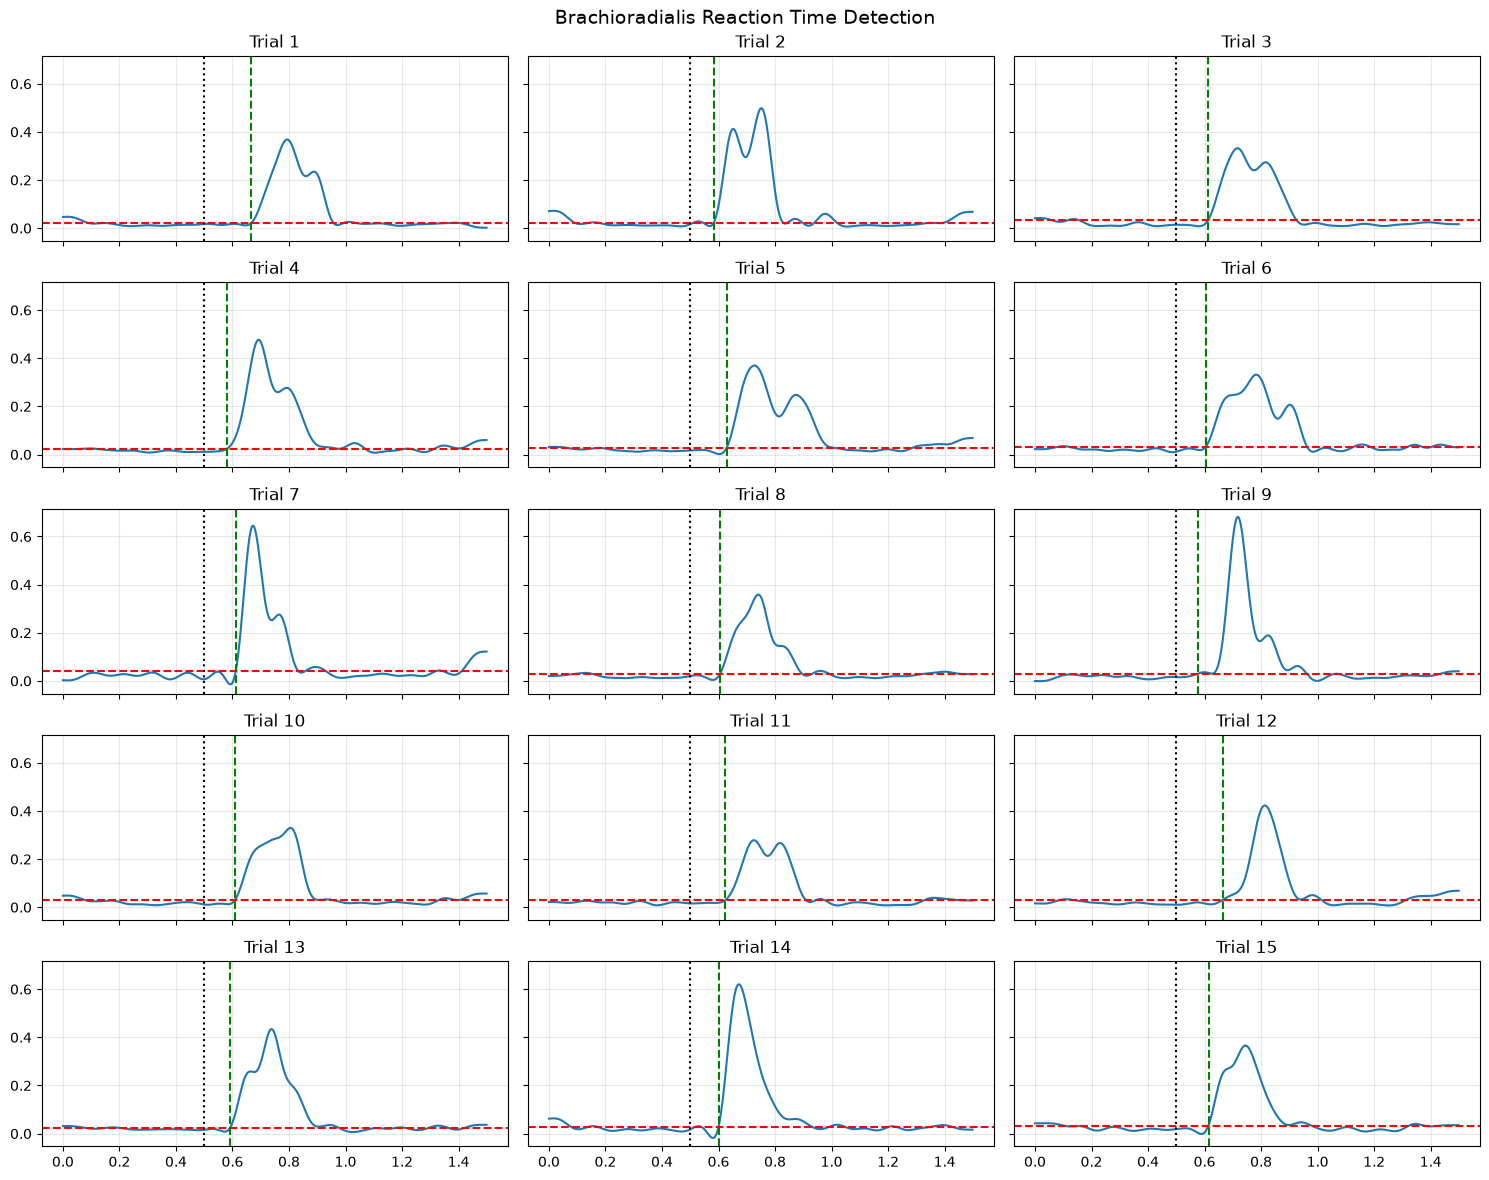

In [6]:
# Config
Fs = int(mat["samplerate"][0][0])
print(f"Sample rate: {Fs} Hz")
fc = 10

n_trials = 15

ch_trigger = 1
ch_bicep = 5
ch_brachio = 6

# Detection params
baseline_start = 0.1      # s
baseline_end = 0.5        # s

stimulus_time = 0.5       # s
search_end = 1.4          # s

min_duration = 0.05       # s
window_ms = 50            # ms

# Sample indices
baseline_start_idx = int(baseline_start * Fs)
baseline_end_idx = int(baseline_end * Fs)

stimulus_idx = int(stimulus_time * Fs)
search_end_idx = int(search_end * Fs)

min_samples = int(min_duration * Fs)
window = int(window_ms * Fs / 1000)

# Extract epochs
trigger_epochs = np.array([
    get_epoch(ch_trigger, trial, mat)
    for trial in range(n_trials)
])

bicep_epochs = np.array([
    get_epoch(ch_bicep, trial, mat)
    for trial in range(n_trials)
])

brachio_epochs = np.array([
    get_epoch(ch_brachio, trial, mat)
    for trial in range(n_trials)
])

# Rectify
biceps_rectified = np.abs(bicep_epochs)
brachios_rectified = np.abs(brachio_epochs)

# Envelope
b, a = butter(4, fc/(Fs/2), btype='low')

biceps_envelope = [
    filtfilt(b, a, x)
    for x in biceps_rectified
]

brachios_envelope = [
    filtfilt(b, a, x)
    for x in brachios_rectified
]

# Time vector
t = np.arange(trigger_epochs.shape[1]) / Fs


# ============================================================
# 1. SINGLE TRIAL
# ============================================================

trial = 0

stim = trigger_epochs[trial]
biceps = bicep_epochs[trial]
brachio = brachio_epochs[trial]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(t, biceps, label="Biceps EMG")
ax1.plot(t, brachio, label="Brachioradialis EMG")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("EMG Amplitude (mV)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(t, stim, 'k--', label="Stimulus")
ax2.set_ylabel("Stimulus (V)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.title("Trial 1: Raw EMG Signals and Stimulus")
plt.tight_layout()
plt.show()


# ============================================================
# 2. ENVELOPE COMPARISON
# ============================================================

ma_bicep = np.convolve(
    biceps_rectified[0],
    np.ones(window) / window,
    mode='same'
)

ma_brachio = np.convolve(
    brachios_rectified[0],
    np.ones(window) / window,
    mode='same'
)

plt.figure(figsize=(12, 6))

plt.plot(
    t,
    ma_bicep * 1000,
    label="Biceps (Moving Average)"
)

plt.plot(
    t,
    biceps_envelope[0] * 1000,
    label="Biceps (Butterworth LPF)"
)

plt.plot(
    t,
    (ma_brachio + 0.0005) * 1000,
    label="Brachioradialis (Moving Average)"
)

plt.plot(
    t,
    (brachios_envelope[0] + 0.0005) * 1000,
    label="Brachioradialis (Butterworth LPF)"
)

plt.title("Envelope Extraction Comparison")
plt.xlabel("Time (s)")
plt.ylabel("Envelope Amplitude (mV)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 3. ALL TRIALS
# ============================================================

fig, ax = plt.subplots(
    3, 1,
    figsize=(12, 8),
    sharex=True
)

for trial in range(n_trials):

    ax[0].plot(
        t,
        trigger_epochs[trial],
        alpha=0.7
    )

    ax[1].plot(
        t,
        biceps_envelope[trial] * 1000,
        alpha=0.7
    )

    ax[2].plot(
        t,
        brachios_envelope[trial] * 1000,
        alpha=0.7
    )

ax[0].set_title("Stimulus Signal")
ax[1].set_title("Biceps Envelope")
ax[2].set_title("Brachioradialis Envelope")

ax[0].set_ylabel("Stimulus (V)")
ax[1].set_ylabel("Amplitude (mV)")
ax[2].set_ylabel("Amplitude (mV)")

ax[2].set_xlabel("Time (s)")

for a in ax:
    a.grid(True, alpha=0.3)

ax[0].set_ylim(-0.5, 8)

plt.suptitle(
    "Overlay of All Trials",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. REACTION TIME
# ============================================================

muscles = [
    ("Biceps", biceps_envelope),
    ("Brachioradialis", brachios_envelope)
]

reaction_times = {}

for name, envelopes in muscles:

    fig, axes = plt.subplots(
        5, 3,
        figsize=(15, 12),
        sharex=True,
        sharey=True
    )

    axes = axes.ravel()

    muscle_reaction = []

    for trial, envelope in enumerate(envelopes):

        baseline = envelope[
            baseline_start_idx:
            baseline_end_idx
        ]

        threshold = (
            np.mean(baseline)
            + 2*np.std(baseline)
        )

        ax = axes[trial]

        ax.plot(t, envelope * 1000)

        ax.axhline(
            threshold * 1000,
            color='r',
            linestyle='--'
        )

        ax.axvline(
            stimulus_time,
            color='k',
            linestyle=':'
        )

        ax.set_title(f"Trial {trial+1}")
        ax.grid(True, alpha=0.3)

        detect_count = 0
        onset_start = None
        onset_time = np.nan

        for i, emg in enumerate(
            envelope[stimulus_idx:search_end_idx]
        ):

            if emg > threshold:

                if onset_start is None:
                    onset_start = i

                detect_count += 1

                if detect_count >= min_samples:

                    rt_ms = onset_start * 1000 / Fs

                    onset_time = (
                        stimulus_idx
                        + onset_start
                    ) / Fs

                    print(
                        f"{name} Trial {trial+1}: "
                        f"{rt_ms:.1f} ms"
                    )

                    muscle_reaction.append(rt_ms)

                    break

            else:

                detect_count = 0
                onset_start = None

        else:
            muscle_reaction.append(np.nan)

        if not np.isnan(onset_time):

            ax.axvline(
                onset_time,
                color='g',
                linestyle='--'
            )

    reaction_times[name] = muscle_reaction

    plt.suptitle(
        f"{name} Reaction Time Detection",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

# Convenience
bicep_reaction = reaction_times["Biceps"]
brachio_reaction = reaction_times["Brachioradialis"]

In [7]:
subjects = ["Hanif", "Bharghav", "Sam"]
stimuli = ["Visual", "Auditory", "Combined"]

# ============================================================
# CONFIG
# ============================================================

fc = 10  # envelope LPF cutoff

baseline_start = 0.1      # s
baseline_end = 0.5        # s

stimulus_time = 0.5       # s
search_end = 1.4          # s

min_duration = 0.05       # s (50 ms)

# ============================================================
# PROCESS DATA
# ============================================================

data = {}

for subject in subjects:

    data[subject] = {}

    for stimulus in stimuli:

        print(f"Loading {subject} - {stimulus}")

        filename = f"{subject}_{stimulus}_1.mat"
        mat = loadmat(filename)

        Fs = int(mat["samplerate"][0][0])

        n_trials = 15

        # ----------------------------------------
        # Sample indices
        # ----------------------------------------

        baseline_start_idx = int(baseline_start * Fs)
        baseline_end_idx = int(baseline_end * Fs)

        stimulus_idx = int(stimulus_time * Fs)
        search_end_idx = int(search_end * Fs)

        min_samples = int(min_duration * Fs)

        # ----------------------------------------
        # Envelope filter
        # ----------------------------------------

        b, a = butter(
            4,
            fc / (Fs / 2),
            btype="low"
        )

        # ----------------------------------------
        # Epoch extraction
        # ----------------------------------------

        trigger_epochs = np.array([
            get_epoch(1, trial, mat)
            for trial in range(n_trials)
        ])

        bicep_epochs = np.array([
            get_epoch(5, trial, mat)
            for trial in range(n_trials)
        ])

        brachio_epochs = np.array([
            get_epoch(6, trial, mat)
            for trial in range(n_trials)
        ])

        # ----------------------------------------
        # Rectification
        # ----------------------------------------

        bicep_rectified = np.abs(bicep_epochs)
        brachio_rectified = np.abs(brachio_epochs)

        # ----------------------------------------
        # Envelope extraction
        # ----------------------------------------

        bicep_envelope = np.array([
            filtfilt(b, a, x)
            for x in bicep_rectified
        ])

        brachio_envelope = np.array([
            filtfilt(b, a, x)
            for x in brachio_rectified
        ])

        # ----------------------------------------
        # Store signals
        # ----------------------------------------

        data[subject][stimulus] = {

            "mat": mat,
            "Fs": Fs,

            "trigger": trigger_epochs,

            "bicep": bicep_epochs,
            "brachio": brachio_epochs,

            "bicep_rectified": bicep_rectified,
            "brachio_rectified": brachio_rectified,

            "bicep_envelope": bicep_envelope,
            "brachio_envelope": brachio_envelope,
        }

        # ----------------------------------------
        # Reaction time detection
        # ----------------------------------------

        for muscle in ("bicep", "brachio"):

            reaction_times = []
            thresholds = []

            envelopes = data[subject][stimulus][
                f"{muscle}_envelope"
            ]

            for envelope in envelopes:

                baseline = envelope[
                    baseline_start_idx:
                    baseline_end_idx
                ]

                mu = np.mean(baseline)
                sigma = np.std(baseline)

                threshold = mu + 2 * sigma

                thresholds.append(threshold)

                detect_count = 0
                onset_start = None

                for i, emg in enumerate(
                    envelope[
                        stimulus_idx:
                        search_end_idx
                    ]
                ):

                    if emg > threshold:

                        if onset_start is None:
                            onset_start = i

                        detect_count += 1

                        if detect_count >= min_samples:

                            rt_ms = (
                                onset_start
                                * 1000
                                / Fs
                            )

                            reaction_times.append(
                                rt_ms
                            )

                            break

                    else:

                        detect_count = 0
                        onset_start = None

                else:

                    reaction_times.append(
                        np.nan
                    )

            data[subject][stimulus][
                f"{muscle}_reaction"
            ] = np.array(reaction_times)

            data[subject][stimulus][
                f"{muscle}_thresholds"
            ] = np.array(thresholds)

Loading Hanif - Visual
Loading Hanif - Auditory
Loading Hanif - Combined
Loading Bharghav - Visual
Loading Bharghav - Auditory
Loading Bharghav - Combined
Loading Sam - Visual
Loading Sam - Auditory
Loading Sam - Combined


In [11]:
for subject in data:
    for stimulus in data[subject]:

        b_rt = np.array(data[subject][stimulus]["bicep_reaction"])
        br_rt = np.array(data[subject][stimulus]["brachio_reaction"])

        print(f"\n{subject} - {stimulus}")
        print(
            f"Bicep {np.nanmean(b_rt):.1f}±{np.nanstd(b_rt, ddof=1):.1f} ms "
            f"[{np.nanmin(b_rt):.0f}-{np.nanmax(b_rt):.0f}] "
            f"NaN={np.isnan(b_rt).sum()} | "
            f"Brachio {np.nanmean(br_rt):.1f}±{np.nanstd(br_rt, ddof=1):.1f} ms "
            f"[{np.nanmin(br_rt):.0f}-{np.nanmax(br_rt):.0f}] "
            f"NaN={np.isnan(br_rt).sum()}"
        )


Hanif - Visual
Bicep 139.5±16.2 ms [118-170] NaN=0 | Brachio 122.2±15.0 ms [94-156] NaN=0

Hanif - Auditory
Bicep 144.0±27.8 ms [117-211] NaN=0 | Brachio 111.6±26.9 ms [75-167] NaN=0

Hanif - Combined
Bicep 133.8±14.5 ms [114-157] NaN=0 | Brachio 119.2±21.5 ms [82-152] NaN=0

Bharghav - Visual
Bicep 171.0±34.2 ms [115-221] NaN=0 | Brachio 247.6±49.4 ms [170-338] NaN=0

Bharghav - Auditory
Bicep 246.0±107.8 ms [132-607] NaN=0 | Brachio 378.4±179.3 ms [207-831] NaN=1

Bharghav - Combined
Bicep 168.0±45.8 ms [106-290] NaN=0 | Brachio 217.9±40.3 ms [159-287] NaN=0

Sam - Visual
Bicep 181.9±65.4 ms [75-302] NaN=0 | Brachio 147.7±51.3 ms [65-295] NaN=0

Sam - Auditory
Bicep 233.3±101.7 ms [39-480] NaN=0 | Brachio 168.3±92.8 ms [81-437] NaN=0

Sam - Combined
Bicep 115.3±20.4 ms [86-150] NaN=0 | Brachio 88.1±31.2 ms [28-141] NaN=0


In [9]:
# Extract reaction times for stats and plotting
rows = []

for subject in data:
    for stimulus in data[subject]:

        b_rt = np.array(data[subject][stimulus]["bicep_reaction"])
        br_rt = np.array(data[subject][stimulus]["brachio_reaction"])

        rows.append({
            "Participant": subject,
            "Stimulus": stimulus,
            "Muscle": "Bicep",
            "RT": np.nanmean(b_rt)
        })

        rows.append({
            "Participant": subject,
            "Stimulus": stimulus,
            "Muscle": "Brachio",
            "RT": np.nanmean(br_rt)
        })

df = pd.DataFrame(rows)

aov = pg.rm_anova(
    dv="RT",
    within=["Stimulus", "Muscle"],
    subject="Participant",
    data=df,
    detailed=True
)

print(aov)

              Source            SS  ddof1  ddof2           MS         F  \
0           Stimulus  16382.465190      2      4  8191.232595  3.145368   
1             Muscle    258.178546      1      2   258.178546  0.036217   
2  Stimulus * Muscle     61.726086      2      4    30.863043  0.055954   

      p_unc  p_GG_corr       ng2       eps  
0  0.151087   0.189337  0.198752  0.686037  
1  0.866635   0.866635  0.003894  1.000000  
2  0.946310   0.835083  0.000934  0.500137  


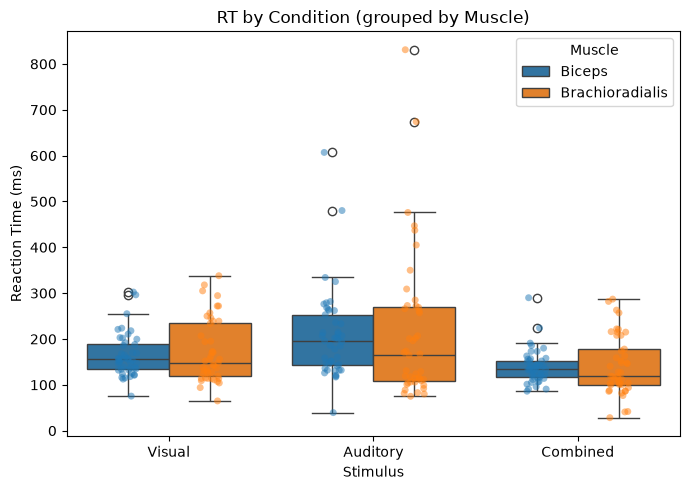

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []

for subject in data:
    for stimulus in data[subject]:

        for rt in data[subject][stimulus]["bicep_reaction"]:
            rows.append([stimulus, "Biceps", rt])

        for rt in data[subject][stimulus]["brachio_reaction"]:
            rows.append([stimulus, "Brachioradialis", rt])

df = pd.DataFrame(
    rows,
    columns=["Stimulus", "Muscle", "RT"]
)

df = df.dropna()

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Stimulus",
    y="RT",
    hue="Muscle"
)

sns.stripplot(
    data=df,
    x="Stimulus",
    y="RT",
    hue="Muscle",
    dodge=True,
    alpha=0.5,
    legend=False
)

plt.ylabel("Reaction Time (ms)")
plt.title("RT by Condition (grouped by Muscle)")
plt.tight_layout()
plt.show()

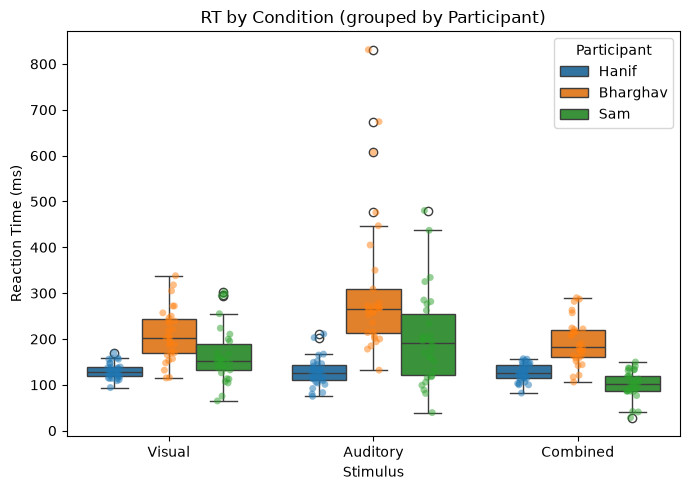

In [14]:
rows = []

for subject in data:
    for stimulus in data[subject]:

        rt_all = (
            list(data[subject][stimulus]["bicep_reaction"])
            + list(data[subject][stimulus]["brachio_reaction"])
        )

        for rt in rt_all:
            rows.append([stimulus, subject, rt])

df = pd.DataFrame(
    rows,
    columns=["Stimulus", "Participant", "RT"]
)

df = df.dropna()

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Stimulus",
    y="RT",
    hue="Participant"
)

sns.stripplot(
    data=df,
    x="Stimulus",
    y="RT",
    hue="Participant",
    dodge=True,
    alpha=0.5,
    legend=False
)

plt.ylabel("Reaction Time (ms)")
plt.title("RT by Condition (grouped by Participant)")
plt.tight_layout()
plt.show()